# Inciso 2:

## Análisis de Delitos en EE.UU (1970) mediante Escalamiento Multidimensional

**Contexto:**

Se analiza una base de datos de actos delictivos en EE.UU. del año 1970. La tabla `crimes.dat` contiene correlaciones entre la ocurrencia de 7 clases de delitos.

**Definición de Distancia:**

Para cada par de delitos (clases), se define la distancia como:

$$
d(x_i, x_j) = 1 - \rho_{ij}
$$

**Objetivo:**

Aplicar **escalamiento multidimensional (MDS)** para visualizar las observaciones en un espacio de menor dimensión e interpretar el primer eje principal.

### Importar y visualizar los datos

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Importar el archivo crimes.dat. Ajusta el parámetro sep si es necesario (aquí se asume que es CSV separado por comas)
df = pd.read_csv("datasets/crimes.dat", sep=",", skipinitialspace=True)

# Visualizamos el DataFrame importado
print("Datos importados:")
print(df.head())

# Configuramos la columna 'Crime' como índice para trabajar cómodamente
df.set_index("Crime", inplace=True)
print("\nDataFrame con índice 'Crime':")
print(df)


Datos importados:
      Crime  No.     1     2     3     4     5     6     7
0    Murder    1  1.00  0.52  0.34  0.81  0.28  0.06  0.11
1      Rape    2  0.52  1.00  0.55  0.70  0.68  0.60  0.44
2   Robbery    3  0.34  0.55  1.00  0.56  0.62  0.44  0.62
3   Assault    4  0.81  0.70  0.56  1.00  0.52  0.32  0.33
4  Burglary    5  0.28  0.68  0.62  0.52  1.00  0.80  0.70

DataFrame con índice 'Crime':
            No.     1     2     3     4     5     6     7
Crime                                                    
Murder        1  1.00  0.52  0.34  0.81  0.28  0.06  0.11
Rape          2  0.52  1.00  0.55  0.70  0.68  0.60  0.44
Robbery       3  0.34  0.55  1.00  0.56  0.62  0.44  0.62
Assault       4  0.81  0.70  0.56  1.00  0.52  0.32  0.33
Burglary      5  0.28  0.68  0.62  0.52  1.00  0.80  0.70
Larceny       6  0.06  0.60  0.44  0.32  0.80  1.00  0.55
Auto theft    7  0.11  0.44  0.62  0.33  0.70  0.55  1.00


### Preparación de la matriz de correlaciones


Matriz de correlaciones:
               1     2     3     4     5     6     7
Crime                                               
Murder      1.00  0.52  0.34  0.81  0.28  0.06  0.11
Rape        0.52  1.00  0.55  0.70  0.68  0.60  0.44
Robbery     0.34  0.55  1.00  0.56  0.62  0.44  0.62
Assault     0.81  0.70  0.56  1.00  0.52  0.32  0.33
Burglary    0.28  0.68  0.62  0.52  1.00  0.80  0.70
Larceny     0.06  0.60  0.44  0.32  0.80  1.00  0.55
Auto theft  0.11  0.44  0.62  0.33  0.70  0.55  1.00


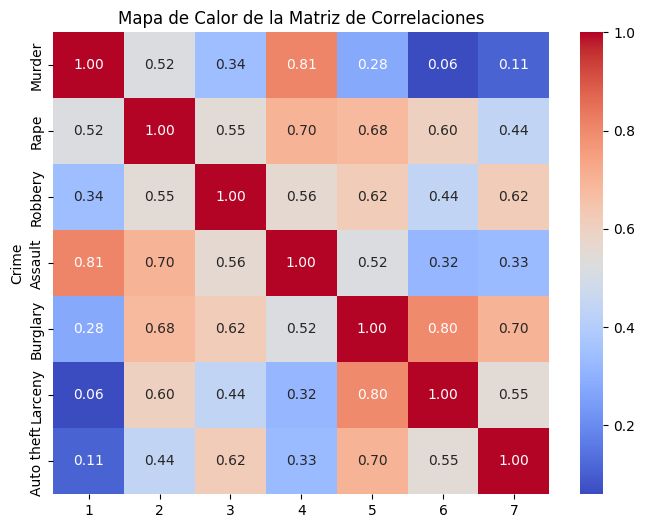

In [33]:
# La tabla incluye una columna "No.", que no es necesaria para el análisis de correlación. La eliminamos.
correlation_matrix = df.drop(columns=["No."]).astype(float)
print("\nMatriz de correlaciones:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de Calor de la Matriz de Correlaciones")
plt.show()

### Cálculo de la matriz de distancias

In [34]:
# Definimos la distancia entre dos variables como: distancia = 1 - correlación
distance_matrix = 1 - correlation_matrix
print("\nMatriz de distancias:")
print(distance_matrix)


Matriz de distancias:
               1     2     3     4     5     6     7
Crime                                               
Murder      0.00  0.48  0.66  0.19  0.72  0.94  0.89
Rape        0.48  0.00  0.45  0.30  0.32  0.40  0.56
Robbery     0.66  0.45  0.00  0.44  0.38  0.56  0.38
Assault     0.19  0.30  0.44  0.00  0.48  0.68  0.67
Burglary    0.72  0.32  0.38  0.48  0.00  0.20  0.30
Larceny     0.94  0.40  0.56  0.68  0.20  0.00  0.45
Auto theft  0.89  0.56  0.38  0.67  0.30  0.45  0.00


### Aplicación de MDS


Coordenadas MDS:
                Dim1      Dim2
Crime                         
Murder      0.209602  0.490927
Rape       -0.102982  0.131432
Robbery     0.238000 -0.145618
Assault     0.125229  0.283502
Burglary   -0.145242 -0.151237
Larceny    -0.350925 -0.203749
Auto theft  0.026318 -0.405257


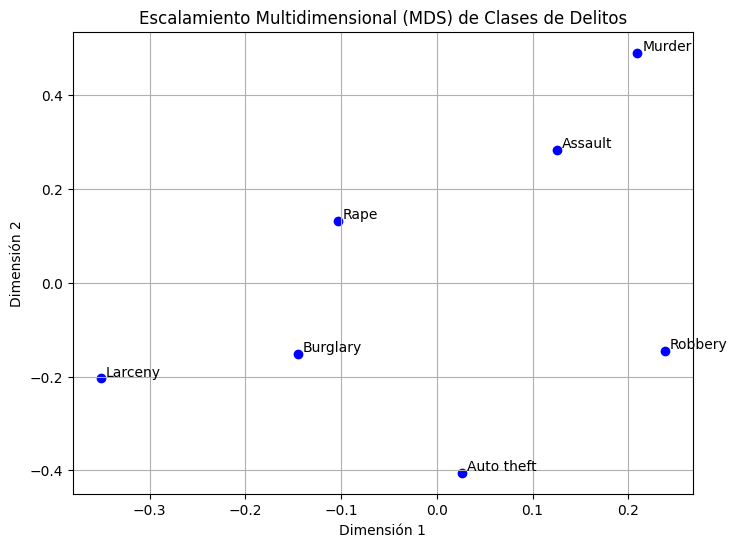

In [35]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

# Configuramos y aplicamos el MDS utilizando la matriz de distancias
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
mds_results = mds.fit_transform(distance_matrix)

# Creamos un DataFrame con las coordenadas obtenidas
mds_df = pd.DataFrame(mds_results, columns=["Dim1", "Dim2"], index=correlation_matrix.index)
print("\nCoordenadas MDS:")
print(mds_df)

# Visualización de los resultados
plt.figure(figsize=(8, 6))
plt.scatter(mds_df["Dim1"], mds_df["Dim2"], color="blue")
for crime in mds_df.index:
    plt.text(mds_df.loc[crime, "Dim1"] + 0.005, mds_df.loc[crime, "Dim2"] + 0.005, crime)
plt.title("Escalamiento Multidimensional (MDS) de Clases de Delitos")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.grid(True)
plt.show()


### Interpretación del Primer Eje Principal con PCA


Cargas PCA:
                 PC1       PC2
Crime                         
Murder      0.591595  0.073182
Rape        0.038288  0.516457
Robbery    -0.117235 -0.414929
Assault     0.379742  0.146707
Burglary   -0.328993  0.269361
Larceny    -0.457468  0.543325
Auto theft -0.416039 -0.408009


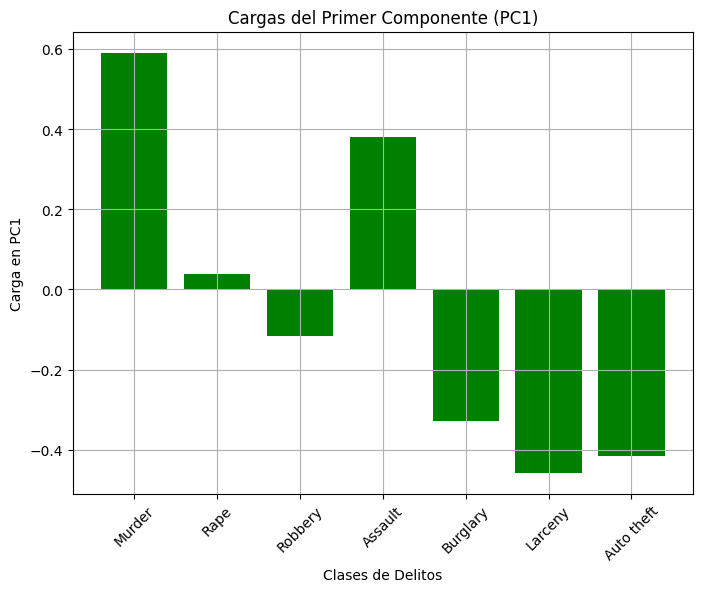

In [36]:
from sklearn.decomposition import PCA

# Aplicamos PCA sobre la matriz de correlación para interpretar el primer eje principal.
pca = PCA(n_components=2)
pca_results = pca.fit_transform(correlation_matrix)

# Creamos un DataFrame para visualizar las cargas de cada variable en los componentes
pca_df = pd.DataFrame(pca.components_.T, index=correlation_matrix.index, columns=["PC1", "PC2"])
print("\nCargas PCA:")
print(pca_df)

# Visualizamos las cargas del primer componente
plt.figure(figsize=(8, 6))
plt.bar(pca_df.index, pca_df["PC1"], color="green")
plt.title("Cargas del Primer Componente (PC1)")
plt.xlabel("Clases de Delitos")
plt.ylabel("Carga en PC1")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


# Inciso 4:

## Factoración NNMF y Sistema de Recomendación con Filtrado Colaborativo

Construir un sistema de recomendación de filtro colaborativo para el conjunto de películas `movies.csv`, usando como base las recomendaciones de los usuarios en `ratings.csv` y el método de factoración no-negativa de matrices (NNMF). Para ello, puede usar las ideas que vimos en el notebook `recommender.ipynb`.

**Requerimientos:**

1. **Métricas y Selección de Vecinos:**
   - Seleccione una métrica apropiada (por ejemplo, similitud coseno) para calcular los vecinos más cercanos entre usuarios.
   - Decida los parámetros de `topNeigh` (número de vecinos a considerar) y `topMovies` (número de películas a recomendar) según su criterio.

2. **Implementación:**
   - Utilice NNMF para descomponer la matriz de ratings y obtener las matrices latentes \( W \) (usuarios) y \( H \) (películas).
   - Construya una función `recommender` que reciba:
     - `userId`: el identificador del usuario.
     - `topNeigh`: el número de vecinos a considerar.
     - `topMovies`: el número de películas a recomendar.
   - La función debe:
     - Calcular la similitud entre el usuario y el resto usando la métrica seleccionada.
     - Seleccionar los vecinos más similares.
     - Predecir los ratings para las películas no vistas por el usuario.
     - Devolver la lista o DataFrame de las películas recomendadas.

3. **Ejemplo y Contraste:**
   - Muestre ejemplos de varias recomendaciones para 3 usuarios diferentes.
   - Contraste las recomendaciones de su modelo con el top de películas mejor calificadas (globalmente) que el usuario no ha visto.


In [37]:
# Importar librerías y cargar datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity

# Cargar datasets
ratings = pd.read_csv('datasets/ratings.csv', header=0, sep=',')
movies = pd.read_csv('datasets/movies.csv', header=0, sep=',')

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)


Ratings shape: (100836, 4)
Movies shape: (9742, 3)


### Preprocesamiento de Datos

Se crea la tabla pivot (usuarios x películas) y se filtra el dataset para seleccionar solo las películas con al menos 20 ratings.


In [38]:
# Crear la tabla pivot (usuarios x películas)
table = pd.pivot_table(ratings, index='userId', columns='movieId', values='rating', fill_value=0)
table = table.astype(int)
print("Tabla pivot shape:", table.shape)

# Filtrar películas con al menos 20 ratings
movie_stats = ratings.groupby('movieId')[['rating']].agg(['count', 'mean'])
movie_stats.columns = movie_stats.columns.droplevel()
cut = 20
movies_sample = movie_stats[movie_stats['count'] >= cut]
lista = list(movies_sample.index)

# Seleccionar solo las columnas correspondientes a las películas filtradas
df = table[[x for x in movies_sample.index]]
Xs = df.values
print("DataFrame filtrado shape:", df.shape)


Tabla pivot shape: (610, 9724)
DataFrame filtrado shape: (610, 1297)


### Factorización NNMF

Se realiza la descomposición de la matriz de ratings usando NNMF para obtener las matrices \( W \) (usuarios) y \( H \) (películas) en un espacio latente de dimensión \( k \).


In [39]:
# Factorización NNMF
k = 20
model = NMF(n_components=k, init='random', max_iter=1000, random_state=2024)
W = model.fit_transform(Xs)
H = model.components_
print("W shape:", W.shape, "H shape:", H.shape)


W shape: (610, 20) H shape: (20, 1297)


### Definición de Funciones de Recomendación

Se definen dos funciones:
- **recommender(userId, topNeigh, topMov):**  
  Calcula la similitud coseno entre usuarios a partir de la matriz \( W \), selecciona los vecinos más cercanos y predice ratings para películas no vistas utilizando un promedio ponderado de los ratings de los vecinos.  
- **top_rated_by_user(userId, topN):**  
  Retorna el top de películas que el usuario ya calificó, ordenado según la calificación.


In [40]:
def recommender(userId, topNeigh=10, topMov=10):
    # Obtener el índice del usuario en el DataFrame
    try:
        user_index = df.index.get_loc(userId)
    except KeyError:
        raise ValueError(f"El userId {userId} no se encuentra en el DataFrame de ratings.")
    
    # Calcular la similitud coseno entre todos los usuarios usando sus vectores en W
    sim_matrix = cosine_similarity(W)
    sim_user = sim_matrix[user_index].copy()
    sim_user[user_index] = 0  # Excluir al propio usuario

    # Seleccionar los índices de los topNeigh vecinos
    neighbor_indices = np.argsort(sim_user)[::-1][:topNeigh]

    # Obtener las películas que el usuario no ha calificado
    user_ratings = df.values[user_index]
    unseen_movie_idx = np.where(user_ratings == 0)[0]

    # Predecir rating para cada película no vista usando promedio ponderado de ratings de vecinos
    predictions = {}
    for movie_idx in unseen_movie_idx:
        numerator = 0
        denominator = 0
        for neigh in neighbor_indices:
            rating = df.values[neigh, movie_idx]
            if rating > 0:  # Consideramos solo ratings existentes
                numerator += sim_user[neigh] * rating
                denominator += sim_user[neigh]
        predictions[movie_idx] = numerator / denominator if denominator > 0 else 0

    # Seleccionar las topMov películas con mayor rating predicho
    recommended_movie_idx = sorted(predictions, key=predictions.get, reverse=True)[:topMov]
    recommended_movieIds = df.columns[recommended_movie_idx]
    
    # Retornar la información de estas películas a partir del DataFrame movies
    recommendations = movies[movies['movieId'].isin(recommended_movieIds)]
    return recommendations

def top_rated_by_user(userId, topN=10):
    try:
        user_index = df.index.get_loc(userId)
    except KeyError:
        raise ValueError(f"El userId {userId} no se encuentra en el DataFrame de ratings.")
    
    user_ratings = df.values[user_index]
    # Obtener los índices de las películas ya calificadas
    rated_idx = np.where(user_ratings > 0)[0]
    if len(rated_idx) == 0:
        return pd.DataFrame()  # Usuario sin ratings previos
    # Ordenar índices por rating de forma descendente
    sorted_idx = rated_idx[np.argsort(user_ratings[rated_idx])[::-1]]
    top_movie_idx = sorted_idx[:topN]
    top_movieIds = df.columns[top_movie_idx]
    return movies[movies['movieId'].isin(top_movieIds)]


### Ejemplo de Uso para Todos los Usuarios

A continuación se recorre cada usuario del DataFrame `df` y se muestran:  
- Las recomendaciones personalizadas basadas en NNMF y filtrado colaborativo.  
- El top de películas ya calificadas por el usuario.


In [41]:
# Recorrer todos los usuarios y mostrar las recomendaciones
usuarios_ejemplo = [1, 2, 3]

# for user in df.index:
for user in usuarios_ejemplo:
    print(f"\n--- Recomendaciones para el usuario {user} ---")
    
    # Recomendaciones basadas en NNMF y vecinos colaborativos
    rec_model = recommender(user, topNeigh=10, topMov=10)
    print("Recomendaciones basadas en NNMF y vecinos colaborativos:")
    display(rec_model.sort_values(by='movieId'))
    
    # Top de películas ya calificadas por el usuario
    rec_top = top_rated_by_user(user, topN=10)
    print("Top de películas ya calificadas por el usuario:")
    display(rec_top.sort_values(by='movieId'))
    print("-" * 50)



--- Recomendaciones para el usuario 1 ---
Recomendaciones basadas en NNMF y vecinos colaborativos:


,movieId,title,genres
23,24,Powder (1995),Drama|Sci-Fi
167,198,Strange Days (1995),Action|Crime|Drama|Mystery|Sci-Fi|Thriller
249,288,Natural Born Killers (1994),Action|Crime|Thriller
276,317,"Santa Clause, The (1994)",Comedy|Drama|Fantasy
277,318,"Shawshank Redemption, The (1994)",Crime|Drama
395,454,"Firm, The (1993)",Drama|Thriller
809,1059,William Shakespeare's Romeo + Juliet (1996),Drama|Romance
889,1186,"Sex, Lies, and Videotape (1989)",Drama
901,1199,Brazil (1985),Fantasy|Sci-Fi
922,1221,"Godfather: Part II, The (1974)",Crime|Drama


Top de películas ya calificadas por el usuario:


,movieId,title,genres
2302,3052,Dogma (1999),Adventure|Comedy|Fantasy
2372,3147,"Green Mile, The (1999)",Crime|Drama
2579,3448,"Good Morning, Vietnam (1987)",Comedy|Drama|War
2581,3450,Grumpy Old Men (1993),Comedy
2674,3578,Gladiator (2000),Action|Adventure|Drama
2733,3671,Blazing Saddles (1974),Comedy|Western
2764,3702,Mad Max (1979),Action|Adventure|Sci-Fi
2765,3703,"Road Warrior, The (Mad Max 2) (1981)",Action|Adventure|Sci-Fi|Thriller
2836,3793,X-Men (2000),Action|Adventure|Sci-Fi
3673,5060,M*A*S*H (a.k.a. MASH) (1970),Comedy|Drama|War


--------------------------------------------------

--- Recomendaciones para el usuario 2 ---
Recomendaciones basadas en NNMF y vecinos colaborativos:


...

--------------------------------------------------

--- Recomendaciones para el usuario 3 ---
Recomendaciones basadas en NNMF y vecinos colaborativos:


,movieId,title,genres
2,3,Grumpier Old Men (1995),Comedy|Romance
23,24,Powder (1995),Drama|Sci-Fi
43,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
95,107,Muppet Treasure Island (1996),Adventure|Children|Comedy|Musical
201,235,Ed Wood (1994),Comedy|Drama
249,288,Natural Born Killers (1994),Action|Crime|Thriller
291,333,Tommy Boy (1995),Comedy
322,364,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX
363,419,"Beverly Hillbillies, The (1993)",Comedy
422,485,Last Action Hero (1993),Action|Adventure|Comedy|Fantasy


Top de películas ya calificadas por el usuario:


,movieId,title,genres
656,849,Escape from L.A. (1996),Action|Adventure|Sci-Fi|Thriller
974,1275,Highlander (1986),Action|Adventure|Fantasy
1054,1371,Star Trek: The Motion Picture (1979),Adventure|Sci-Fi
1190,1587,Conan the Barbarian (1982),Action|Adventure|Fantasy
1567,2105,Tron (1982),Action|Adventure|Sci-Fi
1701,2288,"Thing, The (1982)",Action|Horror|Sci-Fi|Thriller
2765,3703,"Road Warrior, The (Mad Max 2) (1981)",Action|Adventure|Sci-Fi|Thriller


--------------------------------------------------
